In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  

#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io

C:\Users\kanha\AppData\Local\Temp\ipykernel_27008\1312583015.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader


In [1]:
## CLIP Model

import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] =os.getenv("OPENAI_API_KEY")




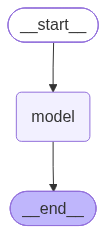

In [4]:
from langchain.agents import create_agent
def get_weather(city:str)->str:
    """Get the current weather for a given city."""
    return f"The weather in {city} is Sunny"
agent=create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    system_prompt="You are helpful agent",
 
)
agent

In [12]:
## Step 4: LLM and prompt
import os
from dotenv import load_dotenv

load_dotenv()
API=os.getenv("OPENAI_API_KEY")
llm=init_chat_model(model="groq:llama-3.3-70b-versatile",api_key=API)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000256D0372FD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000256D03708D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [13]:
llm.invoke("Write an 200 paragraph on artificial intelligence")

AIMessage(content='Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, and decision-making. The field of AI has experienced significant growth in recent years, with advancements in machine learning and deep learning enabling the creation of sophisticated AI systems. These systems have the potential to revolutionize various industries, including healthcare, finance, and transportation, by automating tasks, improving efficiency, and enhancing accuracy. AI-powered systems can analyze vast amounts of data, identify patterns, and make predictions, allowing for informed decision-making and improved outcomes. As AI technology continues to evolve, it is likely to have a profound impact on society, transforming the way we live, work, and interact with one another. With its vast potential, AI is poised to become an integral part of our daily lives, driving innovation 

In [15]:
llm.stream('Write an 200 paragraph on artificial intelligence')

<generator object BaseChatModel.stream at 0x00000256CE1AEAE0>

In [18]:
for chunk in llm.stream('Write an 200 paragraph on artificial intelligence'):
    print(chunk.text,end="|",flush="True")

|Art|ificial| intelligence| (|AI|)| has| revolution|ized| the| way| we| live| and| work|,| transforming| numerous| industries| and| aspects| of| our| daily| lives|.| AI| refers| to| the| development| of| computer| systems| that| can| perform| tasks| that| typically| require| human| intelligence|,| such| as| learning|,| problem|-solving|,| and| decision|-making|.| From| virtual| assistants| like| Siri| and| Alexa| to| self|-driving| cars| and| personalized| product| recommendations|,| AI| is| omnip|resent|.| The| technology| has| made| significant| strides| in| recent| years|,| with| advancements| in| machine| learning|,| natural| language| processing|,| and| computer| vision|.| As| AI| continues| to| evolve|,| it| is| expected| to| have| a| profound| impact| on| various| sectors|,| including| healthcare|,| finance|,| education|,| and| transportation|,| leading| to| increased| efficiency|,| productivity|,| and| innovation|.| With| its| vast| potential|,| AI| is| poised| to| shape| the| 

# Batch


In [19]:
responses=llm.batch([
    "Why do parrots have cloroful feather",
    "How do aeroplane fly",
    "What is AI"
])
for response in responses:
    print(response)

content='I think you meant to ask "Why do parrots have colorful feathers?"\n\nParrots have colorful feathers due to a combination of biological, evolutionary, and environmental factors. Here are some reasons why:\n\n1. **Communication and signaling**: Bright colors can help parrots communicate with each other, especially during courtship, mating, and territorial displays. Different colors can convey information about an individual\'s species, sex, age, health, and social status.\n2. **Camouflage and concealment**: While it may seem counterintuitive, some parrots\' bright colors can actually help them blend in with their surroundings. For example, the green plumage of some parrot species can help them merge with the foliage of their rainforest habitats.\n3. **Visual display and intimidation**: Parrots\' vibrant colors can also serve as a visual display to intimidate predators or rivals. Bright colors can make a parrot appear larger or more formidable, deterring potential threats.\n4. **

In [21]:
responses=llm.batch([
    "Why do parrots have cloroful feather",
    "How do aeroplane fly",
    "What is AI"],
    config={
        "max_concurrency":2
    }
)
for response in responses:
    print(response)

content='I think you meant to ask "Why do parrots have colorful feathers?"\n\nParrots have colorful feathers for several reasons:\n\n1. **Communication and Expression**: Colorful feathers help parrots communicate with each other. Different colors can signal aggression, courtship, or warning calls. For example, some parrots will display bright colors to attract a mate or to warn off predators.\n2. **Camouflage and Adaptation**: While it may seem counterintuitive, colorful feathers can actually help parrots blend in with their surroundings. Many parrots have feathers that match the colors of their environment, such as the greens and blues of the rainforest. This helps them avoid predators and sneak up on prey.\n3. **Thermoregulation**: Some research suggests that the bright colors of parrots\' feathers can help regulate their body temperature. Darker feathers can absorb heat, while lighter feathers can reflect it, helping the parrot maintain a stable body temperature.\n4. **Visual Attrac